# AutoML Benchmark Analysis

**Comparative Evaluation of AutoML Frameworks for Tabular Data in Resource-Constrained Environments**

Reads `results/logs.csv` (105 rows: 5 frameworks x 3 tiers x 7 datasets) and produces:

1. Master summary table — mean F1, time, RAM per framework per tier
2. Pareto frontier plot — accuracy vs. memory tradeoff per tier
3. Degradation curves — F1 drop as resources shrink per framework
4. Failure heatmap — completion status across all 105 runs
5. Recommendation matrix — which framework for which context


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
FIGURES = Path("../figures")
FIGURES.mkdir(exist_ok=True)

TIER_ORDER = ["constrained", "moderate", "unconstrained"]
FRAMEWORKS = ["autogluon", "pycaret", "flaml", "autosklearn", "h2o"]

logs = pd.read_csv("../results/logs.csv")
logs["tier"] = pd.Categorical(logs["tier"], categories=TIER_ORDER, ordered=True)
logs["completed"] = logs["status"].eq("completed")
print(f"{len(logs)} runs loaded, {logs['completed'].sum()} completed")
logs.head()

105 runs loaded, 100 completed


,framework,dataset,tier,f1,auc,rmse,time_sec,peak_ram_mb,cpu_pct,status,completed
0,flaml,titanic,constrained,0.7812,0.8165,NaN,60.4,221.1,161.1,completed,True
1,flaml,wine_quality,constrained,0.6657,NaN,NaN,60.4,279.4,177.2,completed,True
2,flaml,ames_housing,constrained,NaN,NaN,24180.2311,61.0,300.0,186.0,completed,True
3,flaml,california_housing,constrained,NaN,NaN,44520.2754,62.5,276.0,189.0,completed,True
4,flaml,bank_marketing,constrained,0.9127,0.9501,NaN,60.5,308.4,186.6,completed,True


## 1. Master summary table

Mean F1 (classification), RMSE (regression), training time, and peak RAM per framework per tier — completed runs only.

In [2]:
completed = logs[logs["completed"]]

summary = (
    completed.groupby(["framework", "tier"], observed=True)
    .agg(
        mean_f1=("f1", "mean"),
        mean_rmse=("rmse", "mean"),
        mean_time_sec=("time_sec", "mean"),
        mean_peak_ram_mb=("peak_ram_mb", "mean"),
        mean_cpu_pct=("cpu_pct", "mean"),
        runs_completed=("completed", "sum"),
    )
    .round(3)
)
summary

mean_f1  mean_rmse  mean_time_sec  \
framework   tier                                               
autogluon   constrained      0.837  39913.515         65.614   
            moderate         0.846  42166.682        112.143   
            unconstrained    0.846  39626.778        109.800   
autosklearn constrained      0.817  59409.062         59.729   
            moderate         0.842  37263.995        122.886   
            unconstrained    0.847  37245.657        248.414   
flaml       constrained      0.845  34350.253         61.200   
            moderate         0.843  35511.306        121.129   
            unconstrained    0.857  34615.574        241.829   
h2o         constrained      0.837  34191.034         75.129   
            moderate         0.853  33899.606        130.029   
            unconstrained    0.853  33781.444        250.586   
pycaret     constrained      0.885  38487.895         78.133   
            moderate         0.889  36024.485        615.800   
            unconstrained    0.882  48363.039        705.150   

                           mean_peak_ram_mb  mean_cpu_pct  runs_completed  
framework   tier                                                           
autogluon   constrained             769.414       168.514               7  
            moderate               1243.829       304.886               7  
            unconstrained          1198.343       340.100               7  
autosklearn constrained            2168.914        16.100               7  
            moderate               5673.086        35.414               7  
            unconstrained          8681.729        41.200               7  
flaml       constrained             360.043       176.686               7  
            moderate                400.043       335.700               7  
            unconstrained           551.243       340.229               7  
h2o         constrained            1352.057         2.643               7  
            moderate               1735.471         2.014               7  
            unconstrained          1983.229         1.143               7  
pycaret     constrained            1034.550        22.850               6  
            moderate               1777.450         5.700               6  
            unconstrained          1843.650         5.925               4

## 2. Pareto frontier: accuracy vs. memory per tier

Each point is one framework's mean weighted F1 (classification datasets) against its mean peak RAM within a tier. Up and to the left is better.

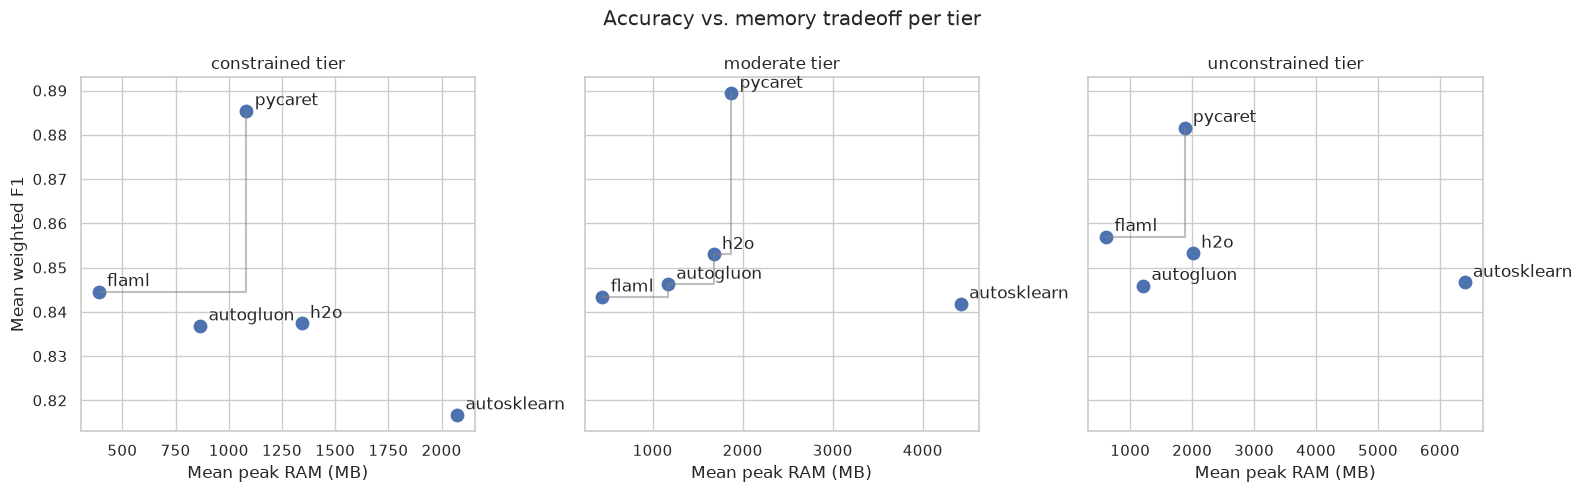

In [3]:
clf = completed[completed["f1"].notna()]
agg = (
    clf.groupby(["framework", "tier"], observed=True)
    .agg(f1=("f1", "mean"), ram=("peak_ram_mb", "mean"))
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, tier in zip(axes, TIER_ORDER):
    sub = agg[agg["tier"] == tier]
    ax.scatter(sub["ram"], sub["f1"], s=80)
    for _, r in sub.iterrows():
        ax.annotate(r["framework"], (r["ram"], r["f1"]),
                    textcoords="offset points", xytext=(6, 4))
    # Pareto frontier: sort by RAM, keep points with a new best F1
    front = sub.sort_values("ram")
    best, xs, ys = -np.inf, [], []
    for _, r in front.iterrows():
        if r["f1"] > best:
            best = r["f1"]; xs.append(r["ram"]); ys.append(r["f1"])
    ax.step(xs, ys, where="post", alpha=0.5, color="grey")
    ax.set_title(f"{tier} tier")
    ax.set_xlabel("Mean peak RAM (MB)")
axes[0].set_ylabel("Mean weighted F1")
fig.suptitle("Accuracy vs. memory tradeoff per tier")
fig.tight_layout()
fig.savefig(FIGURES / "pareto_plot.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Degradation curves

How much does each framework's mean F1 drop as resources shrink from the unconstrained tier down to the constrained tier?

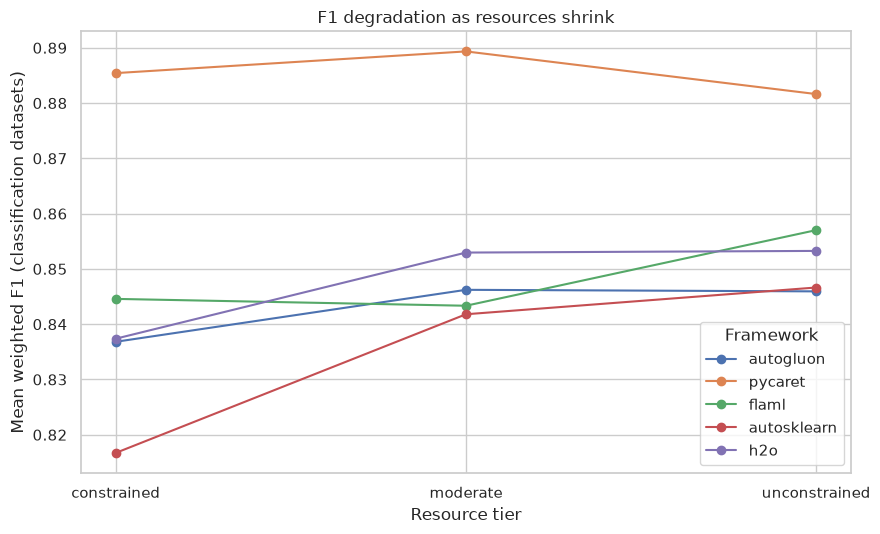

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for fw in FRAMEWORKS:
    sub = (
        clf[clf["framework"] == fw]
        .groupby("tier", observed=False)["f1"].mean()
        .reindex(TIER_ORDER)
    )
    ax.plot(TIER_ORDER, sub.values, marker="o", label=fw)
ax.set_xlabel("Resource tier")
ax.set_ylabel("Mean weighted F1 (classification datasets)")
ax.set_title("F1 degradation as resources shrink")
ax.legend(title="Framework")
fig.tight_layout()
fig.savefig(FIGURES / "degradation_curves.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Failure heatmap

Completion status for every (framework, dataset) cell in each tier:
`2 = completed`, `1 = timeout`, `0 = failed`.

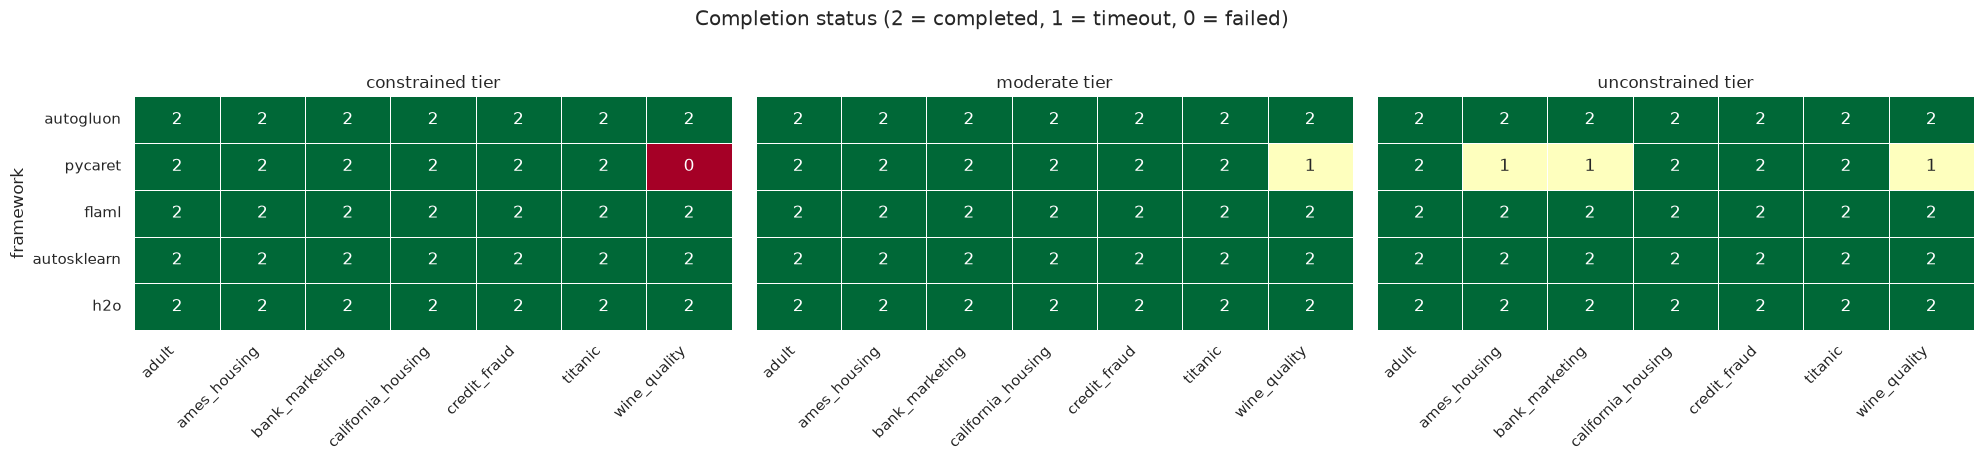

In [5]:
status_code = logs["status"].map(
    lambda s: 2 if s == "completed" else (1 if s == "timeout" else 0)
)
logs["status_code"] = status_code

fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))
for i, (ax, tier) in enumerate(zip(axes, TIER_ORDER)):
    pivot = (
        logs[logs["tier"] == tier]
        .pivot_table(index="framework", columns="dataset",
                     values="status_code", aggfunc="min")
        .reindex(FRAMEWORKS)
    )
    show_y = (i == 0)
    sns.heatmap(pivot, ax=ax, cmap="RdYlGn", vmin=0, vmax=2,
                annot=True, cbar=False, linewidths=0.5,
                yticklabels=(FRAMEWORKS if show_y else False))
    ax.set_title(f"{tier} tier")
    ax.set_xlabel("")
    ax.set_ylabel("framework" if show_y else "")
    if show_y:
        ax.set_yticklabels(FRAMEWORKS, rotation=0)
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
fig.suptitle("Completion status (2 = completed, 1 = timeout, 0 = failed)", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES / "failure_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Recommendation matrix

For each tier: the best framework by mean F1, the most memory-efficient among near-best performers, and the completion rate — the practical selection guide for each hardware context.

In [6]:
# Per-framework completion rate within each tier (all 7 datasets).
completion = (
    logs.groupby(["framework", "tier"], observed=True)["completed"]
    .mean().round(2).rename("completion_rate").reset_index()
)

rows = []
for tier in TIER_ORDER:
    tsub = agg[agg["tier"] == tier].merge(
        completion[completion["tier"] == tier][["framework", "completion_rate"]],
        on="framework", how="left",
    )
    tier_logs = logs[logs["tier"] == tier]
    if tsub.empty:
        continue
    # Highest mean F1 (note: averaged over completed cells only).
    best = tsub.loc[tsub["f1"].idxmax()]
    # Most memory-efficient among near-best performers (within 2 F1 points).
    near = tsub[tsub["f1"] >= best["f1"] - 0.02]
    efficient = near.loc[near["ram"].idxmin()]
    # Most reliable: highest completion rate, F1 as tiebreak — the pick that
    # matters most on constrained hardware where finishing at all is the risk.
    reliable = tsub.sort_values(["completion_rate", "f1"], ascending=False).iloc[0]
    rows.append({
        "tier": tier,
        "best_f1_framework": best["framework"],
        "best_f1": round(best["f1"], 3),
        "best_f1_completion": best["completion_rate"],
        "most_efficient_near_best": efficient["framework"],
        "efficient_peak_ram_mb": round(efficient["ram"], 0),
        "most_reliable": reliable["framework"],
        "reliable_completion": reliable["completion_rate"],
        "reliable_f1": round(reliable["f1"], 3),
    })

recommendation = pd.DataFrame(rows)
recommendation

,tier,best_f1_framework,best_f1,best_f1_completion,most_efficient_near_best,efficient_peak_ram_mb,most_reliable,reliable_completion,reliable_f1
0,constrained,pycaret,0.885,0.86,pycaret,1083.0,flaml,1.0,0.845
1,moderate,pycaret,0.889,0.86,pycaret,1873.0,h2o,1.0,0.853
2,unconstrained,pycaret,0.882,0.57,pycaret,1877.0,flaml,1.0,0.857


---

*All experiments seeded at 42; resource tiers enforced via Docker. See `README.md` for the full experiment design.*